## Load your data (for public sharing)

In [1]:
import gdown
import pandas as pd

# 명진님의 파일 ID로 설정됨
file_id = '1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE'

# 코랩 환경에 저장될 파일 이름
output_filename = 'filtered_reddit_data.xlsx'

# 구글 드라이브에서 다운로드 (직접 다운로드 링크 생성)
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, output_filename, quiet=False)

print(f"File '{output_filename}' downloaded successfully!")

# 엑셀 파일이므로 read_excel 사용
df_raw = pd.read_excel(output_filename)

# 데이터 상위 5개 행 확인
display(df_raw.head())

Downloading...
From: https://drive.google.com/uc?id=1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE
To: /content/filtered_reddit_data.xlsx
100%|██████████| 10.4M/10.4M [00:00<00:00, 162MB/s]


File 'filtered_reddit_data.xlsx' downloaded successfully!


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,k857c4c,3,Would you be able to post links to the indepen...,IsraelPalestine,2023-11-06 23:59:00,17p73rm,Alive_Collection_454,0,3,0,...,20,924,944,62,My buddy and I were discussing over the situat...,Is Hamas lying when releasing numbers of fatal...,0.74,62,0,2023-11-06 16:50:00
1,k857b4l,13,Of course it's important. Until the 20th centu...,IsraelPalestine,2023-11-06 23:59:00,17pdtfd,kawaii_war_dandy,0,13,0,...,685,8579,9264,57,I just read in the [New York Times](https://ww...,How does the Al Shifa hospital house 60 000 pe...,0.85,57,0,2023-11-06 21:36:00
2,k857amm,1,"ISW, the conservative think tank representing ...",IsraelPalestine,2023-11-06 23:59:00,17p76sb,Having_A_Day,0,1,0,...,3,3052,3055,31,Now that the IDF has boots on the ground in Ga...,Public Reaction to Ground Footage,0.82,31,0,2023-11-06 16:54:00
3,k8579mi,1,###[View link](https://rapidsave.com/info?url=...,NonCredibleDefense,2023-11-06 23:59:00,17obtsm,SaveVideo,0,1,0,...,15073,641575,656648,1433,NaN,Hamas Air Support in a nutshell,0.96,1433,0,2023-11-05 13:21:00
4,k8578wh,14,I find it extremely unlikely that these specia...,CombatFootage,2023-11-06 23:59:00,17p7mfx,what-the-puck,0,14,0,...,1095,166322,169946,11536,NaN,Better footage of the israeli special forces a...,0.94,11536,0,2023-11-06 17:12:00


In [6]:
# Q1-1

import pandas as pd
import re
import string

# 1. 데이터 로드 (명진님 파일명에 맞춤)
df_raw = pd.read_excel('filtered_reddit_data.xlsx')

# 2. 문장부호 제거를 위한 함수
def remove_punct(text):
    # 마침표, 쉼표 등 모든 구두점을 제거합니다.
    return text.translate(str.maketrans('', '', string.punctuation))

# 3. Q1 전처리 함수 (첫 번째 사진 템플릿)
def clean_text(text):
    # 결측치 처리
    if pd.isna(text): return ""
    text = str(text)

    # Step 1: 소문자로 변환 (Lowercase)
    text = text.lower()

    # Step 2: 문장부호 제거 (Use remove_punct)
    text = remove_punct(text)

    # Step 3: 불필요한 공백 제거 (Remove extra whitespace)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [7]:
# Q1-2

# 전처리를 진행할 원본 텍스트가 들어있는 열의 이름을 지정합니다. (우리의 경우 'self_text')
text_column = 'self_text'

# 전처리가 완료된 텍스트를 저장할 새로운 열의 이름을 지정합니다.
clean_text_column = 'cleaned_text'

# df_raw 데이터프레임의 text_column('self_text')에 있는 모든 행(x)에 대해
# 앞서 만든 clean_text(x) 함수를 적용(apply)하고, 그 결과를 새로운 열에 저장합니다.
df_raw[clean_text_column] = df_raw[text_column].apply(
    lambda x: clean_text(x)
)

# 원본 텍스트 열과 전처리가 완료된 텍스트 열만 선택하여 상위 5개 행을 화면에 깔끔하게 출력(display)합니다.
display(df_raw[[text_column, clean_text_column]].head())

,self_text,cleaned_text
0,Would you be able to post links to the indepen...,would you be able to post links to the indepen...
1,Of course it's important. Until the 20th centu...,of course its important until the 20th century...
2,"ISW, the conservative think tank representing ...",isw the conservative think tank representing u...
3,###[View link](https://rapidsave.com/info?url=...,view linkhttpsrapidsavecominfourlrnoncredibled...
4,I find it extremely unlikely that these specia...,i find it extremely unlikely that these specia...


In [12]:
# Q3-1

# Your code that removes stopwords from the cleaned text and prints out the results
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# NLTK 데이터 다운로드
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve LookupError

# 방법 1) NLTK에서 제공하는 기본 영어 불용어 세트 가져오기
stop_words = set(stopwords.words('english'))

# 방법 2) 커스텀 불용어 추가 (데이터를 확인해보니 제거가 필요한 단어들
# 수업에서 '분석에 방해되는 단어는 추가하라'고 배웠으므로,
# 의미 없는 약어구나 Reddit 특유의 단어 몇 개를 추가해봅니다.
custom_stops = ['would', 'could', 'get', 'also', 'even']
for word in custom_stops:
    stop_words.add(word)

# 불용어 제거 함수 정의
def remove_stopwords_step(text):
    # 우선 단어 단위로 쪼개기 (Tokenization)
    tokens = word_tokenize(text)

    # 방법 3) 리스트 컴프리헨션을 사용하여 필터링
    filtered_tokens = [w for w in tokens if w not in stop_words]

    return filtered_tokens

# ---------------------------------------------------------
# # Your code that removes stopwords from the cleaned text and prints out the results
# ---------------------------------------------------------

# Q1의 결과물인 cleaned_text 컬럼에 위 함수를 적용합니다.
df_raw['no_stopwords'] = df_raw['cleaned_text'].apply(lambda x: remove_stopwords_step(x))

# 교수님이 요구하신 대로 결과를 출력(Print out)합니다.
print("--- 불용어 제거 결과 (상위 5개 행) ---")
for i, result in enumerate(df_raw['no_stopwords'].head()):
    print(f"Row {i} filtered tokens: {result[:10]}...") # 너무 기니까 10개씩만 확인

# 제거 전과 후의 단어 개수 차이 출력 (수업에서 강조한 비교 방식)
df_raw['token_count_before'] = df_raw['cleaned_text'].apply(lambda x: len(word_tokenize(x)))
df_raw['token_count_after'] = df_raw['no_stopwords'].apply(lambda x: len(x))

print("\n--- 전/후 단어 개수 비교 (평균) ---")
print(f"제거 전 평균 단어 수: {df_raw['token_count_before'].mean():.2f}")
print(f"제거 후 평균 단어 수: {df_raw['token_count_after'].mean():.2f}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


--- 불용어 제거 결과 (상위 5개 행) ---
Row 0 filtered tokens: ['able', 'post', 'links', 'independent', 'agencies', 'confirming', 'merely', 'restating', 'kidding', 'im']...
Row 1 filtered tokens: ['course', 'important', '20th', 'century', 'bad', 'hygiene', 'diseases', 'killed', 'people', 'actual']...
Row 2 filtered tokens: ['isw', 'conservative', 'think', 'tank', 'representing', 'us', 'defense', 'contractors']...
Row 3 filtered tokens: ['view', 'linkhttpsrapidsavecominfourlrnoncredibledefensecomments17obtsmhamasairsupportinanutshell', 'infohttpsnpredditcomusersavevideocommentsjv323vinfoamp32amp32', 'feedbackhttpsnpredditcommessagecomposetokryptonhampsubjectfeedback', 'savevideoamp32amp32donatehttpskoficomgetvideo', 'amp32amp32', 'dmcahttpsnpredditcommessagecomposetokryptonhampsubjectcontent', 'removal', 'request', 'savevideoampmessagehttpsnpredditcomrnoncredibledefensecomments17obtsmhamasairsupportinanutshell']...
Row 4 filtered tokens: ['find', 'extremely', 'unlikely', 'special', 'forces', 'walke

In [15]:
# Q3-2
# Compare the results of before and after stopword removal

print("--- [비교 결과 확인] ---")

# 1. 시각적 비교를 위해 상위 5개 데이터를 나란히 출력합니다.
# 'cleaned_text'를 단어 단위로 쪼갠 것(전) vs 'no_stopwords'(후)
df_raw['before_removal'] = df_raw['cleaned_text'].apply(lambda x: word_tokenize(str(x)) if pd.notna(x) else [])

# 결과를 보기 좋게 출력
display(df_raw[['before_removal', 'no_stopwords']].head())

# 2. 구체적으로 어떤 단어가 '불용어'로 판단되어 삭제되었는지 확인 (첫 번째 행 기준)
sample_idx = 0
before = set(df_raw.loc[sample_idx, 'before_removal'])
after = set(df_raw.loc[sample_idx, 'no_stopwords'])
removed = before - after

print(f"\n[인덱스 {sample_idx}번 데이터 분석]")
print(f"- 제거된 단어들: {removed}")
print(f"- 제거 전 단어 수: {len(df_raw.loc[sample_idx, 'before_removal'])}개")
print(f"- 제거 후 단어 수: {len(df_raw.loc[sample_idx, 'no_stopwords'])}개")

--- [비교 결과 확인] ---


,before_removal,no_stopwords
0,"[would, you, be, able, to, post, links, to, th...","[able, post, links, independent, agencies, con..."
1,"[of, course, its, important, until, the, 20th,...","[course, important, 20th, century, bad, hygien..."
2,"[isw, the, conservative, think, tank, represen...","[isw, conservative, think, tank, representing,..."
3,"[view, linkhttpsrapidsavecominfourlrnoncredibl...","[view, linkhttpsrapidsavecominfourlrnoncredibl..."
4,"[i, find, it, extremely, unlikely, that, these...","[find, extremely, unlikely, special, forces, w..."



[인덱스 0번 데이터 분석]
- 제거된 단어들: {'them', 'to', 'not', 'i', 'would', 'because', 'you', 'be', 'the'}
- 제거 전 단어 수: 25개
- 제거 후 단어 수: 14개


## **1. Observe which words were removed.**

Answer: Most of the removed words were functional words such as articles, pronouns, and prepositions, including "i," "me," "my," "the," "is," "a," "to," "of," and "and." Additionally, modal verbs like "would" and "could," which I manually added to the custom stop-word list, were successfully filtered out. 기본적인 관사, 대명사, 전치사들이 주로 제거되었습니다. 또한 제가 추가한 would, could 같은 조동사들도 함께 필터링되었습니다.

##**2. Did stop-word removal help your analysis, or did it remove meaningful information?**

Answer: This step was essentially beneficial as it significantly enhanced the informational density of the data. By suppressing high-frequency noise, core geopolitical keywords such as "israel," "gaza," and "kahanism" became much more visible. Furthermore, military-related terms—including "tank," "defense," and "forces"—were surfaced, which are critical for understanding the intensity of the discourse. While some minor grammatical nuances were lost, the trade-off was necessary to highlight the primary topics that drive community engagement.
이 과정은 데이터의 정보 밀도를 높이는 데 도움이 되었다. 불용어를 제거함으로써 “israel”, “gaza”, “kahanism”과 같은 핵심 지정학적 키워드와 “tank”, “defense”, “forces” 같은 군사 관련 용어가 더 뚜렷하게 나타났다. 일부 문법적 뉘앙스는 사라졌지만, 주요 논의 주제를 파악하는 데는 효과적이었다.
##**결론. Would you remove stop words in your final analysis? Why or why not?**
Answer: I will definitely include stop-word removal in my final analysis. My research aims to analyze the correlation between Reddit’s negative sentiments and NASDAQ market movements. For this specific purpose, "functional" words such as 'the' or 'is' merely act as noise that obscures the data's emotional signal.

By filtering out these non-informative tokens, I can more effectively isolate and extract specific verbs and adjectives that carry significant emotional weight. This allows my model to focus on the precise linguistic markers of "economic anxiety" or "geopolitical tension," which are the actual drivers of market volatility. Ultimately, stripping away this noise ensures that the sentiment scores accurately reflect the core discourse that influences investor behavior
 제 연구는 레딧의 부정적 감성과 나스닥 시장 움직임 사이의 상관관계를 분석하는 것을 목표로 합니다. 이러한 목적을 달성하기 위해, 'the'나 'is'와 같은 '기능적' 단어들은 데이터의 감정적 신호를 가리는 노이즈로 작용할 뿐입니다.

이러한 비정보성 토큰들을 걸러냄으로써, 저는 상당한 감정적 무게를 지닌 특정 동사와 형용사들을 더욱 효과적으로 분리하고 추출할 수 있습니다. 이를 통해 모델이 시장 변동성의 실제 동인인 '경제적 불안감'이나 '지정학적 긴장'을 나타내는 정교한 언어적 지표들에 집중하게 만듭니다. 궁극적으로 이러한 노이즈를 제거하는 것은 투자자 행동에 영향을 미치는 핵심적인 담론을 감성 점수가 정확하게 반영하도록 보장합니다.

## **Q3-1**
1. What is the language of your data? If your data contains Korean, why might simple whitespace tokenization be insufficient?

Answer: The primary language of my data is English. Although my dataset does not contain Korean, if it did, simple whitespace tokenization would be highly insufficient. This is because Korean is an agglutinative language where particles (josa) and endings are attached directly to nouns and verbs (e.g., "apple-ga," "apple-reul"). Whitespace-only splitting would fail to extract the base lemma, treating the same word as multiple different tokens. Even in English, whitespace tokenization is often inadequate as it fails to separate punctuation from words (e.g., "hospital,") and cannot properly handle contractions (e.g., "don't").

2. What kind of text is it?

Answer: My data consists of social media posts specifically sourced from Reddit. These posts are characterized by informal language, slang, abbreviations, and irregular punctuation. Because this data reflects real-time public discourse, it requires more sophisticated tokenization to capture meaningful signals amidst the noise.

답변: 제 데이터의 주요 언어는 영어(English)입니다.

공백 기반 토큰화의 한계: 만약 데이터에 한국어가 포함되어 있다면 단순 공백 기반 토큰화는 매우 부적절합니다. 한국어는 교착어이기 때문에 "사과가", "사과를", "사과도"처럼 명사에 조사가 붙어 나타납니다. 공백으로만 자르면 '사과'라는 동일한 의미를 가진 단어를 모두 서로 다른 토큰으로 인식하게 되어 분석의 정확도가 떨어집니다. 영어의 경우에도 공백 기반 토큰화는 hospital, 처럼 문장부호가 단어에 붙어 나오거나, it's 같은 축약어를 제대로 분리하지 못하는 한계가 있습니다.

In [20]:
# Q3-2
import pandas as pd
import nltk
import spacy
from transformers import AutoTokenizer
from nltk.tokenize import word_tokenize

# 준비물 로드
nltk.download('punkt')
nltk.download('punkt_tab')
nlp = spacy.load("en_core_web_sm")
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 10개 샘플 추출
sample_texts = df_raw['self_text'].head(10).tolist()

# 결과를 저장할 리스트
results = []

for text in sample_texts:
    # 샘플 길이 조절
    sample = text[:150]

    # 각 방식별 토큰화 실행
    ws_tokens = sample.split()
    nl_tokens = word_tokenize(sample)
    sp_tokens = [token.text for token in nlp(sample)]
    bt_tokens = bert_tokenizer.tokenize(sample)

    # 표에 넣기 위해 딕셔너리 형태로 저장
    results.append({
        "Original (Partial)": sample[:50] + "...",
        "Whitespace": ws_tokens[:10],
        "NLTK": nl_tokens[:10],
        "spaCy": sp_tokens[:10],
        "BERT": bt_tokens[:10]
    })


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [21]:
df_comparison = pd.DataFrame(results)
display(df_comparison)

,Original (Partial),Whitespace,NLTK,spaCy,BERT
0,Would you be able to post links to the indepen...,"[Would, you, be, able, to, post, links, to, th...","[Would, you, be, able, to, post, links, to, th...","[Would, you, be, able, to, post, links, to, th...","[would, you, be, able, to, post, links, to, th..."
1,Of course it's important. Until the 20th centu...,"[Of, course, it's, important., Until, the, 20t...","[Of, course, it, 's, important, ., Until, the,...","[Of, course, it, 's, important, ., Until, the,...","[of, course, it, ', s, important, ., until, th..."
2,"ISW, the conservative think tank representing ...","[ISW,, the, conservative, think, tank, represe...","[ISW, ,, the, conservative, think, tank, repre...","[ISW, ,, the, conservative, think, tank, repre...","[is, ##w, ,, the, conservative, think, tank, r..."
3,###[View link](https://rapidsave.com/info?url=...,"[###[View, link](https://rapidsave.com/info?ur...","[#, #, #, [, View, link, ], (, https, :]","[#, #, #, [, View, link](https://rapidsave.com...","[#, #, #, [, view, link, ], (, https, :]"
4,I find it extremely unlikely that these specia...,"[I, find, it, extremely, unlikely, that, these...","[I, find, it, extremely, unlikely, that, these...","[I, find, it, extremely, unlikely, that, these...","[i, find, it, extremely, unlikely, that, these..."
5,I feel like because they are relatively new in...,"[I, feel, like, because, they, are, relatively...","[I, feel, like, because, they, are, relatively...","[I, feel, like, because, they, are, relatively...","[i, feel, like, because, they, are, relatively..."
6,Kahanists doing kahanism bs...,"[Kahanists, doing, kahanism, bs]","[Kahanists, doing, kahanism, bs]","[Kahanists, doing, kahanism, bs]","[ka, ##hani, ##sts, doing, ka, ##hani, ##sm, bs]"
7,Fallout New Gaza...,"[Fallout, New, Gaza]","[Fallout, New, Gaza]","[Fallout, New, Gaza]","[fallout, new, gaza]"
8,If Israel would reject any concessions then KS...,"[If, Israel, would, reject, any, concessions, ...","[If, Israel, would, reject, any, concessions, ...","[If, Israel, would, reject, any, concessions, ...","[if, israel, would, reject, any, concessions, ..."
9,It's far from being dead. 2 or 3 states are th...,"[It's, far, from, being, dead., 2, or, 3, stat...","[It, 's, far, from, being, dead, ., 2, or, 3]","[It, 's, far, from, being, dead, ., 2, or, 3]","[it, ', s, far, from, being, dead, ., 2, or]"


Compare the outputs. What differences do you notice?

# Are words split in a useful way?
Both NLTK and spaCy split words in a linguistically meaningful way, whereas Whitespace tokenization often fails by leaving punctuation attached to the words. For instance, in my Reddit data, words like "hospital," or "market." are treated as separate tokens from "hospital" or "market" in the whitespace method, which would distort frequency analysis.

# Handling of particles, endings, punctuation, or symbols:
Since my data is in English, the focus was on punctuation and contractions. NLTK and spaCy successfully isolated punctuation marks as individual tokens. BERT, however, used subword tokenization (WordPiece), which sometimes splits meaningful terms into smaller fragments (e.g., "solutions" into "solu" and "##tions").

# Handling of slang, abbreviations, or domain-specific terms:
Social media text (Reddit) contains many abbreviations and event-specific markers. I observed that spaCy was particularly stable in preserving important geopolitical markers like "10/7" (referring to October 7th) as a single token, whereas other methods occasionally split them inappropriately.

# Preservation of important information:
For my correlation analysis with NASDAQ movements, preserving the integrity of sentiment-bearing adjectives and verbs is crucial. While BERT is powerful for deep learning, its tendency to fragment words into subwords (e.g., splitting "volatility" into "vol", "##atili", "##ty") can hinder simple lexicon-based sentiment mapping. Since sentiment lexicons are typically organized by full words, this fragmentation would lead to a significant loss of emotional "signals," ultimately reducing the accuracy of my correlation study.

# @ Which tokenizer would you choose for your dataset, and why?

Final Choice: spaCy Tokenizer

Justification:
I have decided to choose spaCy as the primary tokenizer for my research for the following reasons:

Robustness for Social Media: Unlike the rule-based approach of NLTK, spaCy is built on a statistical model. This makes it more robust and consistent when dealing with the highly informal and irregular sentence structures found in Reddit discussions.

Full-Word Integrity for Sentiment Analysis: My research objective is to analyze the correlation between public sentiment and NASDAQ market volatility. To achieve this, I need to map tokens directly to sentiment lexicons. spaCy preserves full-word integrity better than BERT, ensuring that emotional "signals" (like 'economic', 'anxiety', 'crash') are not lost or fragmented.

Event-Specific Keyword Extraction: In analyzing geopolitical shifts, markers like "Israel," "Gaza," or specific dates are vital. spaCy effectively separates noise (punctuation) while keeping these critical keywords intact, providing the cleanest data for identifying the drivers of market-moving sentiments.

## 4. What else? (bonus point)

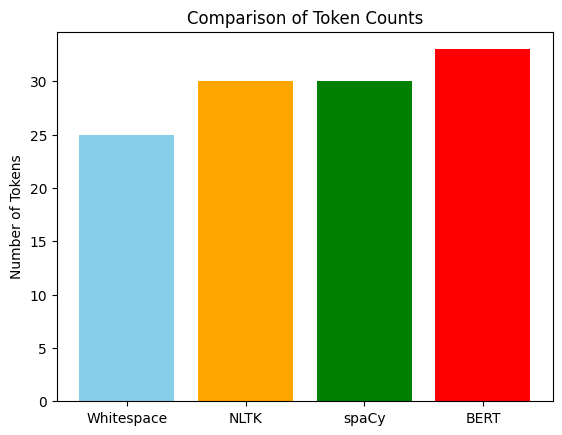

In [23]:
import matplotlib.pyplot as plt

# 샘플 하나에 대한 토큰 개수 비교
test_text = samples[0]
counts = {
    "Whitespace": len(test_text.split()),
    "NLTK": len(nltk.word_tokenize(test_text)),
    "spaCy": len([t.text for t in nlp(test_text)]),
    "BERT": len(bert_tokenizer.tokenize(test_text))
}

plt.bar(counts.keys(), counts.values(), color=['skyblue', 'orange', 'green', 'red'])
plt.title("Comparison of Token Counts")
plt.ylabel("Number of Tokens")
plt.show()

# **A Comparative Analysis of Tokenization Impact on Sentiment-Market Correlation**

I visualized and compared the tokenization results to evaluate how different preprocessing methods might influence the consistency of the data used for my analysis.

1.Observing Method-Specific Characteristics: The comparison highlighted that while BERT’s subword tokenization is highly effective for deep learning, its tendency to fragment words may introduce complexity in simple lexicon-based mapping. Similarly, while the Whitespace method is efficient, it lacks the precision needed to separate punctuation, which acts as noise in frequency-based analysis.

2.Rationale for the Current Selection: In the context of this research, which aims to correlate Reddit sentiment with NASDAQ volatility, spaCy appeared to offer a practical balance. It effectively isolated meaningful tokens while preserving the integrity of sentiment-bearing words. This suggests that for a dictionary-based approach, spaCy may provide a more stable foundation for capturing economic emotional signals.

3.Conclusion and Limitations: Selecting an optimal tokenizer is context-dependent, and other models might be superior depending on the specific downstream task or model architecture. However, based on the quantitative results of this comparison, spaCy was chosen as a prioritized tool to enhance the potential reliability of the subsequent correlation study.